# Case Study: Dự đoán số lượng lỗi phần mềm bằng Deep Learning

Notebook này làm theo quy trình chính của bài báo **Predicting the Number of Software Faults using Deep Learning** với 3 project đã chọn: **Lucene, Poi, Xalan**.

Quy trình gồm: gộp CSV → phân tích dữ liệu → xóa trùng/thiếu → SMOTEND-like oversampling → log transformation → standardization → chia train/test 70/30 → train CNN, MLP → đánh giá MSE, Kendall → vẽ loss → so sánh thêm DTR, SVR.

> Trong CSV, biến mục tiêu là `bug`. Trong bài báo, biến này được gọi là `fault`.

## 1. Import thư viện

Nếu chạy trên Colab mà thiếu thư viện, cell này sẽ tự cài các package cần thiết.

In [ ]:
from pathlib import Path
import re
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

from scipy.stats import kendalltau

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Concatenate, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")

RANDOM_STATE = 10
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

## 2. Khai báo đường dẫn và các project

Đặt notebook cùng cấp với thư mục `PROMISE-BACKUP`, hoặc sửa `BASE_PATH` cho đúng.

In [21]:
BASE_PATH = Path("PROMISE-BACKUP/bug-data")
PROJECTS = ["lucene", "poi", "xalan"]

FEATURES = [
    "wmc", "dit", "noc", "cbo",
    "rfc", "lcom", "ca", "ce",
    "npm", "lcom3", "loc", "dam",
    "moa", "mfa", "cam", "ic",
    "cbm", "amc", "max_cc", "avg_cc"
]
TARGET = "bug"

OUTPUT_DIR = Path("outputs_promise_fault_prediction")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Base path:", BASE_PATH.resolve())
print("Projects:", PROJECTS)

Base path: E:\Hoc Tap\HOC MAY_N\PROMISE-backup\bug-data
Projects: ['lucene', 'poi', 'xalan']


## 3. Đọc và gộp các file CSV

Mỗi file CSV là một version của project. Notebook sẽ đọc tất cả file `.csv` trong 3 folder `lucene`, `poi`, `xalan` rồi gộp lại thành một dataset chung.

In [22]:
def extract_version_from_filename(file_path: Path, project: str) -> str:
    stem = file_path.stem
    prefix = project + "-"
    if stem.startswith(prefix):
        return stem.replace(prefix, "", 1)
    match = re.search(r"(\d+(?:\.\d+)*)", stem)
    return match.group(1) if match else stem


def load_selected_projects(base_path: Path, projects: list[str]):
    all_frames = []
    file_summary = []

    if not base_path.exists():
        raise FileNotFoundError(
            f"Không tìm thấy thư mục: {base_path.resolve()}\n"
            "Hãy sửa BASE_PATH cho đúng, ví dụ Path('/content/PROMISE-BACKUP/bug-data')"
        )

    for project in projects:
        folder = base_path / project
        if not folder.exists():
            raise FileNotFoundError(f"Không tìm thấy folder project: {folder.resolve()}")

        csv_files = sorted(folder.glob("*.csv"))
        if len(csv_files) == 0:
            raise FileNotFoundError(f"Folder {folder.resolve()} không có file .csv nào")

        for file in csv_files:
            df = pd.read_csv(file)
            df.columns = [c.strip().lower() for c in df.columns]

            df["project"] = project
            df["version"] = extract_version_from_filename(file, project)
            df["source_file"] = file.name

            all_frames.append(df)
            file_summary.append({
                "project": project,
                "version": extract_version_from_filename(file, project),
                "file": file.name,
                "rows": len(df),
                "columns": len(df.columns)
            })

    merged = pd.concat(all_frames, ignore_index=True)
    return merged, pd.DataFrame(file_summary)

raw_df, file_summary = load_selected_projects(BASE_PATH, PROJECTS)

print("Số file đã đọc:", len(file_summary))
display(file_summary)
print("Kích thước dữ liệu sau khi gộp:", raw_df.shape)
display(raw_df.head())

Số file đã đọc: 11


,project,version,file,rows,columns
0,lucene,2.0,lucene-2.0.csv,195,25
1,lucene,2.2,lucene-2.2.csv,247,25
2,lucene,2.4,lucene-2.4.csv,340,25
3,poi,1.5,poi-1.5.csv,237,25
4,poi,2.0,poi-2.0.csv,314,25
5,poi,2.5,poi-2.5.csv,385,25
6,poi,3.0,poi-3.0.csv,442,25
7,xalan,2.4,xalan-2.4.csv,723,25
8,xalan,2.5,xalan-2.5.csv,803,25
9,xalan,2.6,xalan-2.6.csv,885,25


Kích thước dữ liệu sau khi gộp: (5480, 25)


,name,wmc,dit,noc,cbo,rfc,lcom,ca,ce,npm,lcom3,loc,dam,moa,mfa,cam,ic,cbm,amc,max_cc,avg_cc,bug,project,version,source_file
0,org.apache.lucene.analysis.WhitespaceAnalyzer,2,2,0,3,4,1,0,3,2,2.000000,10,0.0,0,0.666667,0.666667,0,0,4.000000,1,0.5000,0,lucene,2.0,lucene-2.0.csv
1,org.apache.lucene.search.QueryTermVector,10,1,0,4,37,0,0,4,9,0.388889,278,1.0,0,0.000000,0.340000,0,0,26.600000,5,1.6000,0,lucene,2.0,lucene-2.0.csv
2,org.apache.lucene.analysis.PorterStemmer,27,1,0,1,43,13,1,0,13,0.600962,1174,1.0,0,0.000000,0.253086,0,0,42.185185,26,5.7407,0,lucene,2.0,lucene-2.0.csv
3,org.apache.lucene.index.TermPositions,1,1,0,21,1,0,20,1,1,2.000000,1,0.0,0,0.000000,1.000000,0,0,0.000000,1,1.0000,3,lucene,2.0,lucene-2.0.csv
4,org.apache.lucene.analysis.TokenStream,3,1,2,19,4,3,18,1,3,2.000000,7,0.0,0,0.000000,1.000000,0,0,1.333333,1,0.6667,1,lucene,2.0,lucene-2.0.csv


## 4. Kiểm tra cột và tiền xử lý ban đầu

Dùng 20 cột từ `wmc` đến `avg_cc` làm feature. Dùng `bug` làm target. Các cột định danh như `name`, `project`, `version`, `source_file` không đưa vào model.

In [23]:
required_columns = FEATURES + [TARGET]
missing_columns = [col for col in required_columns if col not in raw_df.columns]
if missing_columns:
    raise ValueError("Thiếu các cột bắt buộc: " + str(missing_columns))


def basic_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()

    keep_cols = []
    for col in ["project", "version", "source_file", "name"]:
        if col in cleaned.columns:
            keep_cols.append(col)
    keep_cols += FEATURES + [TARGET]
    cleaned = cleaned[keep_cols].copy()

    for col in FEATURES + [TARGET]:
        cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    print("Kích thước trước xử lý:", cleaned.shape)
    print("Số dòng thiếu dữ liệu:", cleaned[FEATURES + [TARGET]].isna().any(axis=1).sum())
    print("Số dòng trùng lặp:", cleaned.duplicated().sum())

    cleaned = cleaned.dropna(subset=FEATURES + [TARGET])
    cleaned = cleaned.drop_duplicates().reset_index(drop=True)
    cleaned = cleaned[cleaned[TARGET] >= 0].reset_index(drop=True)

    print("Kích thước sau xử lý:", cleaned.shape)
    return cleaned

clean_df = basic_cleaning(raw_df)
display(clean_df.head())

Kích thước trước xử lý: (5480, 25)
Số dòng thiếu dữ liệu: 0
Số dòng trùng lặp: 0
Kích thước sau xử lý: (5480, 25)


,project,version,source_file,name,wmc,dit,noc,cbo,rfc,lcom,ca,ce,npm,lcom3,loc,dam,moa,mfa,cam,ic,cbm,amc,max_cc,avg_cc,bug
0,lucene,2.0,lucene-2.0.csv,org.apache.lucene.analysis.WhitespaceAnalyzer,2,2,0,3,4,1,0,3,2,2.000000,10,0.0,0,0.666667,0.666667,0,0,4.000000,1,0.5000,0
1,lucene,2.0,lucene-2.0.csv,org.apache.lucene.search.QueryTermVector,10,1,0,4,37,0,0,4,9,0.388889,278,1.0,0,0.000000,0.340000,0,0,26.600000,5,1.6000,0
2,lucene,2.0,lucene-2.0.csv,org.apache.lucene.analysis.PorterStemmer,27,1,0,1,43,13,1,0,13,0.600962,1174,1.0,0,0.000000,0.253086,0,0,42.185185,26,5.7407,0
3,lucene,2.0,lucene-2.0.csv,org.apache.lucene.index.TermPositions,1,1,0,21,1,0,20,1,1,2.000000,1,0.0,0,0.000000,1.000000,0,0,0.000000,1,1.0000,3
4,lucene,2.0,lucene-2.0.csv,org.apache.lucene.analysis.TokenStream,3,1,2,19,4,3,18,1,3,2.000000,7,0.0,0,0.000000,1.000000,0,0,1.333333,1,0.6667,1


## 5. Thống kê dữ liệu và phân bố biến mục tiêu

Thống kê số dòng theo project/version:


,project,version,rows
0,lucene,2.0,195
1,lucene,2.2,247
2,lucene,2.4,340
3,poi,1.5,237
4,poi,2.0,314
5,poi,2.5,385
6,poi,3.0,442
7,xalan,2.4,723
8,xalan,2.5,803
9,xalan,2.6,885


Thống kê biến mục tiêu bug:


count    5480.000000
mean        0.951825
std         1.671360
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max        47.000000
Name: bug, dtype: float64

Số class không lỗi bug = 0: 2529
Số class có lỗi bug > 0: 2951
Tỷ lệ class có lỗi: 53.85 %


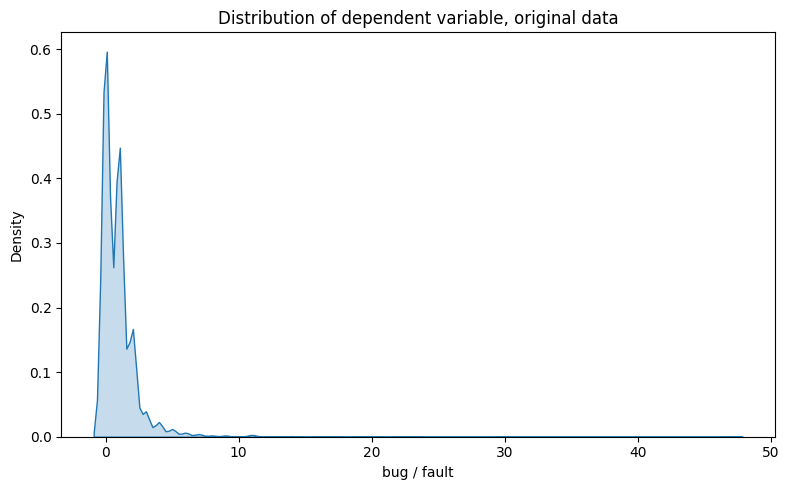

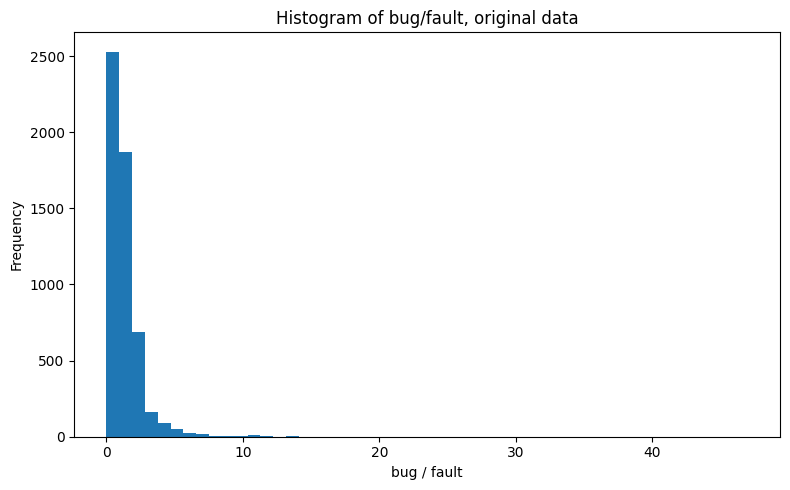

In [24]:
print("Thống kê số dòng theo project/version:")
display(clean_df.groupby(["project", "version"]).size().reset_index(name="rows"))

print("Thống kê biến mục tiêu bug:")
display(clean_df[TARGET].describe())

faulty_count = (clean_df[TARGET] > 0).sum()
non_faulty_count = (clean_df[TARGET] == 0).sum()
print("Số class không lỗi bug = 0:", non_faulty_count)
print("Số class có lỗi bug > 0:", faulty_count)
print("Tỷ lệ class có lỗi:", round(faulty_count / len(clean_df) * 100, 2), "%")

plt.figure(figsize=(8, 5))
sns.kdeplot(clean_df[TARGET], fill=True)
plt.title("Distribution of dependent variable, original data")
plt.xlabel("bug / fault")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_distribution_original_bug.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(clean_df[TARGET], bins=50)
plt.title("Histogram of bug/fault, original data")
plt.xlabel("bug / fault")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_hist_original_bug.png", dpi=200)
plt.show()

## 6. Ma trận tương quan

Cell này vẽ ma trận tương quan đầy đủ và ma trận chỉ hiện các tương quan mạnh, tương tự tinh thần Figure 2 trong bài báo.

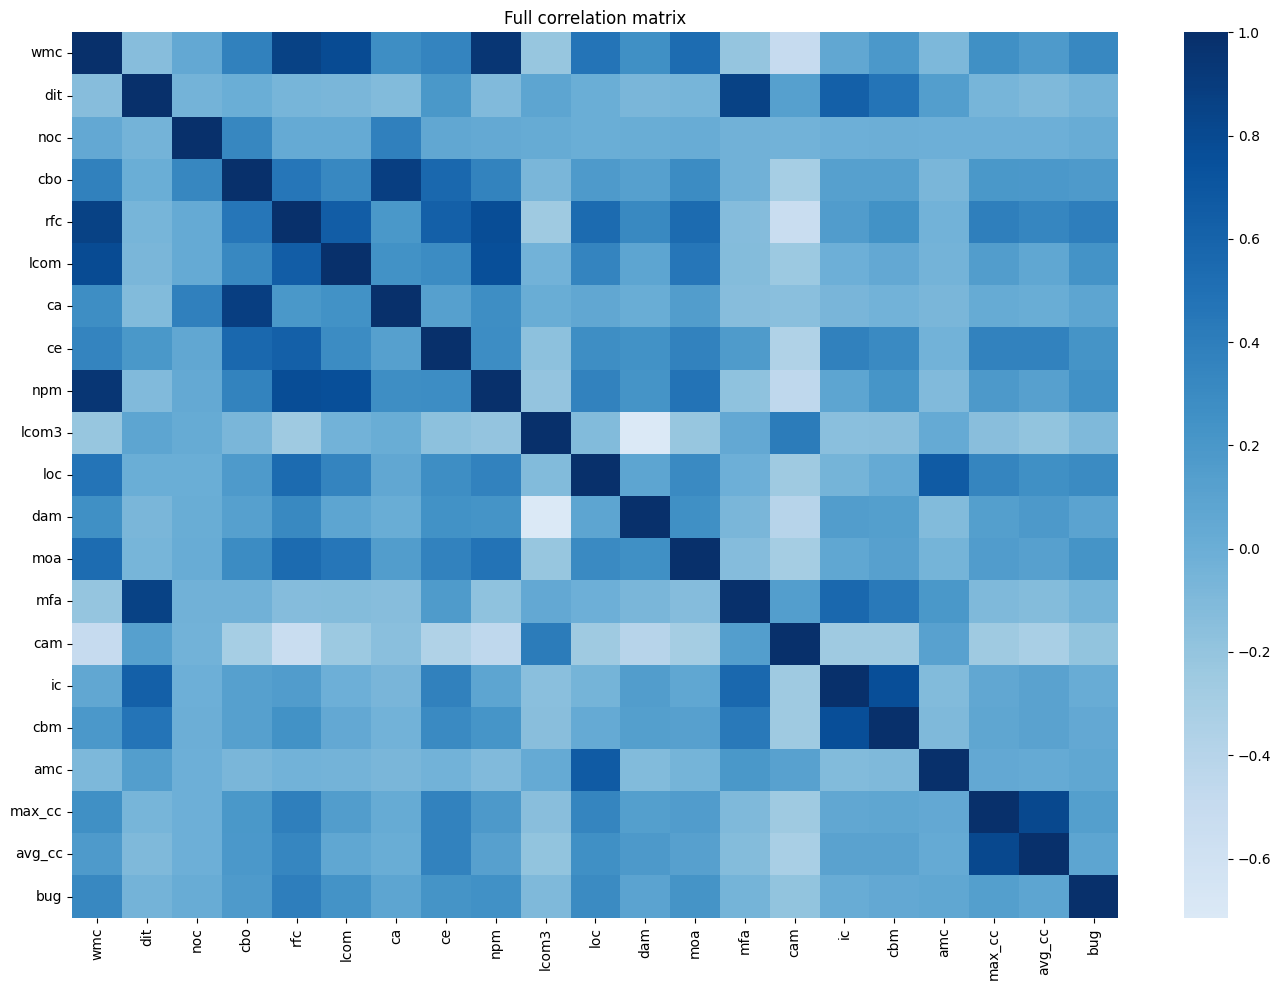

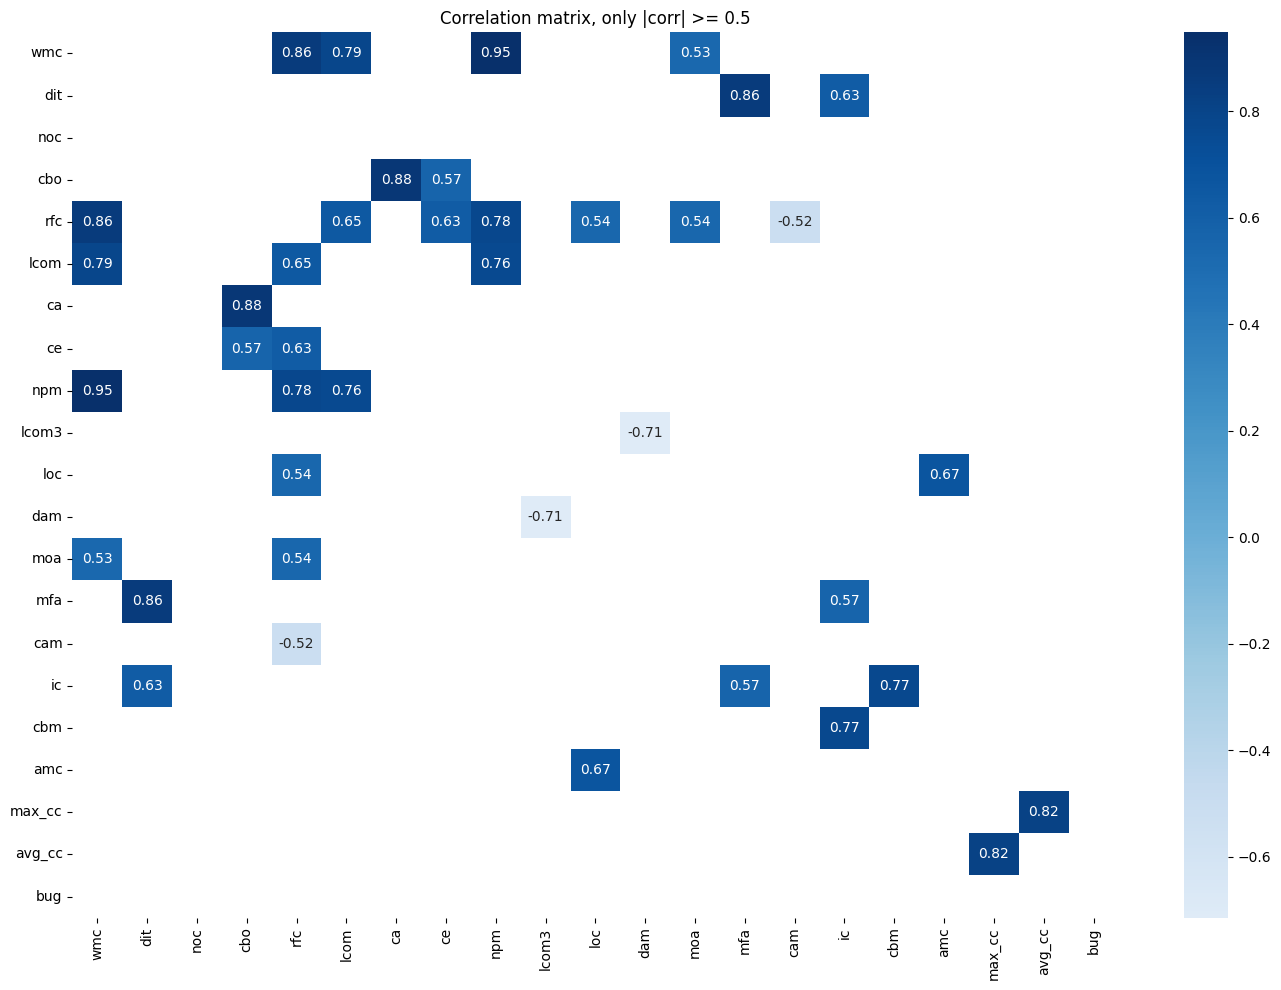

Top feature tương quan với bug theo trị tuyệt đối:


,corr_with_bug
rfc,0.400651
wmc,0.329923
loc,0.298409
npm,0.251465
lcom,0.243038
ce,0.224809
moa,0.223602
cam,-0.189725
cbo,0.171690
max_cc,0.137549


In [25]:
corr = clean_df[FEATURES + [TARGET]].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="Blues", center=0, annot=False)
plt.title("Full correlation matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_full_correlation_matrix.png", dpi=200)
plt.show()

threshold = 0.5
strong_corr = corr.where((corr.abs() >= threshold) & (corr.abs() < 1.0))

plt.figure(figsize=(14, 10))
sns.heatmap(strong_corr, cmap="Blues", center=0, annot=True, fmt=".2f")
plt.title(f"Correlation matrix, only |corr| >= {threshold}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_strong_correlation_matrix.png", dpi=200)
plt.show()

print("Top feature tương quan với bug theo trị tuyệt đối:")
bug_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
display(bug_corr.to_frame("corr_with_bug"))

## 7. Hàm SMOTEND-like oversampling

Bài báo dùng SMOTEND để tăng số lượng bản ghi thuộc nhóm thiểu số, tức class có lỗi `bug > 0`.

Trong Python phổ biến không có hàm chuẩn đúng tên `SMOTEND`, nên notebook này triển khai phiên bản **SMOTE-style / SMOTEND-like**:

- nhóm đa số: `bug = 0`
- nhóm thiểu số: `bug > 0`
- sinh thêm mẫu tổng hợp bằng nội suy giữa các mẫu faulty gần nhau
- nội suy cả feature và `log1p(bug)` để giữ thông tin số lỗi

In [26]:
def smotend_like_oversample(
    X: pd.DataFrame,
    y_bug: pd.Series,
    random_state: int = 42,
    k_neighbors: int = 5,
    target_ratio: float = 1.0,
):
    rng = np.random.default_rng(random_state)

    X_values = X.astype(float).to_numpy()
    y_values = y_bug.astype(float).to_numpy()
    y_log = np.log1p(y_values)

    faulty_mask = y_values > 0
    non_faulty_count = int((~faulty_mask).sum())
    faulty_count = int(faulty_mask.sum())

    desired_faulty_count = int(non_faulty_count * target_ratio)
    n_to_generate = max(0, desired_faulty_count - faulty_count)

    print("Non-faulty count:", non_faulty_count)
    print("Faulty count before:", faulty_count)
    print("Desired faulty count:", desired_faulty_count)
    print("Synthetic faulty samples to generate:", n_to_generate)

    if n_to_generate == 0:
        return X.copy(), y_log.copy()

    X_min = X_values[faulty_mask]
    y_min_log = y_log[faulty_mask]

    if len(X_min) < 2:
        raise ValueError("Không đủ mẫu faulty để sinh mẫu tổng hợp.")

    minority_matrix = np.column_stack([X_min, y_min_log])

    k = min(k_neighbors, len(minority_matrix) - 1)
    nn = NearestNeighbors(n_neighbors=k + 1)
    nn.fit(minority_matrix)
    neighbors = nn.kneighbors(minority_matrix, return_distance=False)

    synthetic_rows = []
    for _ in range(n_to_generate):
        i = rng.integers(0, len(minority_matrix))
        neighbor_candidates = neighbors[i][1:]
        j = rng.choice(neighbor_candidates)
        lam = rng.random()
        synthetic = minority_matrix[i] + lam * (minority_matrix[j] - minority_matrix[i])
        synthetic_rows.append(synthetic)

    synthetic_rows = np.asarray(synthetic_rows)
    X_syn = synthetic_rows[:, :-1]
    y_syn_log = synthetic_rows[:, -1]
    y_syn_log = np.clip(y_syn_log, 0, None)

    X_res_values = np.vstack([X_values, X_syn])
    y_log_res = np.concatenate([y_log, y_syn_log])

    X_res = pd.DataFrame(X_res_values, columns=X.columns)
    return X_res, y_log_res

## 8. Chuẩn bị dữ liệu cho 2 thí nghiệm

- Experiment 1: without SMOTEND
- Experiment 2: with SMOTEND

Cả hai đều dùng `log1p(bug)`, chuẩn hóa bằng `StandardScaler`, và chia train/test 70/30.

In [27]:
def prepare_experiment_data(clean_df: pd.DataFrame, use_smotend: bool):
    X_raw = clean_df[FEATURES].copy()
    y_raw = clean_df[TARGET].copy()

    if use_smotend:
        X_work, y_log = smotend_like_oversample(X_raw, y_raw, random_state=RANDOM_STATE)
    else:
        X_work = X_raw.copy()
        y_log = np.log1p(y_raw.astype(float).to_numpy())

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_work,
        y_log,
        test_size=0.30,
        random_state=RANDOM_STATE,
        shuffle=True,
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    return X_train, X_test, y_train, y_test, scaler, X_work, y_log

X_train_no, X_test_no, y_train_no, y_test_no, scaler_no, X_no, ylog_no = prepare_experiment_data(clean_df, use_smotend=False)
X_train_sm, X_test_sm, y_train_sm, y_test_sm, scaler_sm, X_sm, ylog_sm = prepare_experiment_data(clean_df, use_smotend=True)

print("Experiment 1 - without SMOTEND")
print("Train:", X_train_no.shape, "Test:", X_test_no.shape)
print()
print("Experiment 2 - with SMOTEND-like")
print("Train:", X_train_sm.shape, "Test:", X_test_sm.shape)

Non-faulty count: 2529
Faulty count before: 2951
Desired faulty count: 2529
Synthetic faulty samples to generate: 0
Experiment 1 - without SMOTEND
Train: (3836, 20) Test: (1644, 20)

Experiment 2 - with SMOTEND-like
Train: (3836, 20) Test: (1644, 20)


## 9. Vẽ phân bố sau SMOTEND và sau log transformation

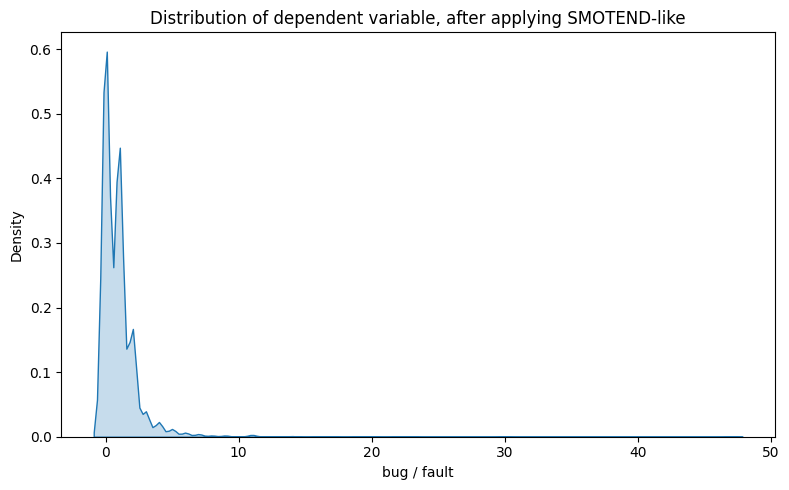

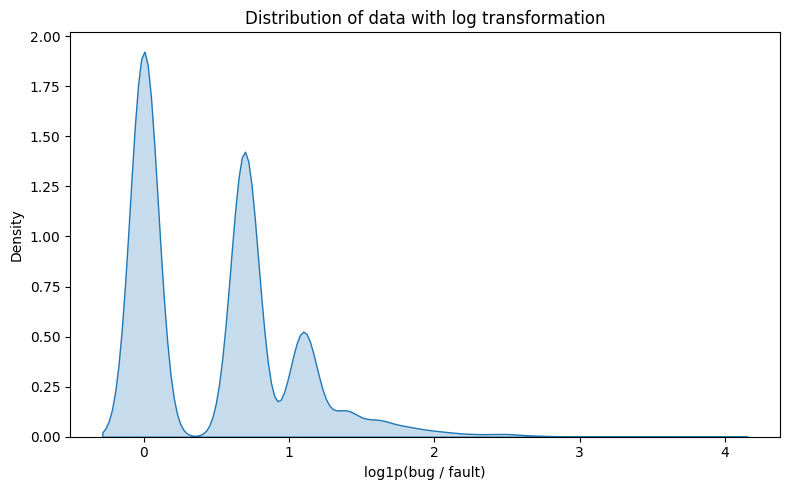

In [28]:
y_sm_as_bug = np.expm1(ylog_sm)

plt.figure(figsize=(8, 5))
sns.kdeplot(y_sm_as_bug, fill=True)
plt.title("Distribution of dependent variable, after applying SMOTEND-like")
plt.xlabel("bug / fault")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_distribution_after_smotend.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
sns.kdeplot(ylog_sm, fill=True)
plt.title("Distribution of data with log transformation")
plt.xlabel("log1p(bug / fault)")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_distribution_log_transform.png", dpi=200)
plt.show()

## 10. Chia 20 feature thành 5 nhóm theo bài báo

In [29]:
FEATURE_GROUPS = [
    ["wmc", "dit", "noc", "cbo"],
    ["rfc", "lcom", "ca", "ce"],
    ["npm", "lcom3", "loc", "dam"],
    ["moa", "mfa", "cam", "ic"],
    ["cbm", "amc", "max_cc", "avg_cc"],
]

feature_to_index = {feature: idx for idx, feature in enumerate(FEATURES)}
GROUP_INDICES = [[feature_to_index[f] for f in group] for group in FEATURE_GROUPS]

for i, group in enumerate(FEATURE_GROUPS, start=1):
    print(f"Group {i}:", group)


def split_groups_for_mlp(X_array: np.ndarray):
    return [X_array[:, idxs] for idxs in GROUP_INDICES]


def split_groups_for_cnn(X_array: np.ndarray):
    return [X_array[:, idxs].reshape(-1, 4, 1) for idxs in GROUP_INDICES]

Group 1: ['wmc', 'dit', 'noc', 'cbo']
Group 2: ['rfc', 'lcom', 'ca', 'ce']
Group 3: ['npm', 'lcom3', 'loc', 'dam']
Group 4: ['moa', 'mfa', 'cam', 'ic']
Group 5: ['cbm', 'amc', 'max_cc', 'avg_cc']


## 11. Xây dựng CNN và MLP

In [30]:
def build_cnn_model(learning_rate: float = 0.001) -> Model:
    inputs = []
    branches = []

    for i in range(5):
        inp = Input(shape=(4, 1), name=f"cnn_group_{i+1}")
        x = Conv1D(
            filters=16,
            kernel_size=2,
            activation="relu",
            kernel_initializer="glorot_uniform",
            name=f"conv_group_{i+1}"
        )(inp)
        x = MaxPooling1D(pool_size=2, name=f"maxpool_group_{i+1}")(x)
        x = Dropout(0.2, name=f"dropout_group_{i+1}")(x)
        x = Flatten(name=f"flatten_group_{i+1}")(x)

        inputs.append(inp)
        branches.append(x)

    merged = Concatenate(name="merge_cnn_groups")(branches)
    x = Dense(64, activation="relu", kernel_initializer="glorot_uniform", name="dense_1")(merged)
    x = Dropout(0.2, name="dropout_after_merge")(x)
    x = Dense(32, activation="relu", kernel_initializer="glorot_uniform", name="dense_2")(x)
    output = Dense(1, activation="linear", name="predicted_faults")(x)

    model = Model(inputs=inputs, outputs=output, name="CNN_fault_prediction")
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return model


def build_mlp_model(learning_rate: float = 0.001) -> Model:
    inputs = []
    branches = []

    for i in range(5):
        inp = Input(shape=(4,), name=f"mlp_group_{i+1}")
        x = Dense(
            16,
            activation="relu",
            kernel_initializer="glorot_uniform",
            name=f"dense_group_{i+1}"
        )(inp)
        x = Flatten(name=f"flatten_group_{i+1}")(x)

        inputs.append(inp)
        branches.append(x)

    merged = Concatenate(name="merge_mlp_groups")(branches)
    x = Dense(64, activation="relu", kernel_initializer="glorot_uniform", name="dense_1")(merged)
    x = Dense(32, activation="relu", kernel_initializer="glorot_uniform", name="dense_2")(x)
    output = Dense(1, activation="linear", name="predicted_faults")(x)

    model = Model(inputs=inputs, outputs=output, name="MLP_fault_prediction")
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return model

sample_cnn = build_cnn_model()
sample_mlp = build_mlp_model()
sample_cnn.summary()
sample_mlp.summary()

Model: "CNN_fault_prediction"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cnn_group_1         │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_group_2         │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_group_3         │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_group_4         │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_group_5         │ (None, 4, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_group_1        │ (None, 3, 16)     │         48 │ cnn_group_1[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_group_2        │ (None, 3, 16)     │         48 │ cnn_group_2[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_group_3        │ (None, 3, 16)     │         48 │ cnn_group_3[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_group_4        │ (None, 3, 16)     │         48 │ cnn_group_4[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_group_5        │ (None, 3, 16)     │         48 │ cnn_group_5[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_group_1     │ (None, 1, 16)     │          0 │ conv_group_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_group_2     │ (None, 1, 16)     │          0 │ conv_group_2[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_group_3     │ (None, 1, 16)     │          0 │ conv_group_3[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_group_4     │ (None, 1, 16)     │          0 │ conv_group_4[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool_group_5     │ (None, 1, 16)     │          0 │ conv_group_5[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_group_1     │ (None, 1, 16)     │          0 │ maxpool_group_1[… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_group_2     │ (None, 1, 16)     │          0 │ maxpool_group_2[

 Total params: 7,537 (29.44 KB)

 Trainable params: 7,537 (29.44 KB)

 Non-trainable params: 0 (0.00 B)

Model: "MLP_fault_prediction"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mlp_group_1         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_group_2         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_group_3         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_group_4         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mlp_group_5         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_group_1       │ (None, 16)        │         80 │ mlp_group_1[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_group_2       │ (None, 16)        │         80 │ mlp_group_2[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_group_3       │ (None, 16)        │         80 │ mlp_group_3[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_group_4       │ (None, 16)        │         80 │ mlp_group_4[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_group_5       │ (None, 16)        │         80 │ mlp_group_5[0][0] │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_group_1     │ (None, 16)        │          0 │ dense_group_1[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_group_2     │ (None, 16)        │          0 │ dense_group_2[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_group_3     │ (None, 16)        │          0 │ dense_group_3[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_group_4     │ (None, 16)        │          0 │ dense_group_4[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_group_5     │ (None, 16)        │          0 │ dense_group_5[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge_mlp_groups    │ (None, 80)        │          0 │ flatten_group_1[… │
│ (Concatenate)       │                   │            │ flatten_group_2[… │
│                     │                   │            │ flatten_group_3[… │
│                     │                   │            │ flatten_group_4[

 Total params: 7,697 (30.07 KB)

 Trainable params: 7,697 (30.07 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Hàm train và đánh giá MSE, Kendall

In [31]:
def safe_kendall(y_true, y_pred):
    result = kendalltau(np.ravel(y_true), np.ravel(y_pred))
    if np.isnan(result.correlation):
        return 0.0
    return float(result.correlation)


def evaluate_regression(y_true, y_pred):
    y_pred = np.ravel(y_pred)
    y_true = np.ravel(y_true)
    return {
        "Kendall": safe_kendall(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred),
    }


def train_deep_model(
    model_name: str,
    experiment_name: str,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    epochs: int = 100,
    batch_size: int = 16,
):
    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE)

    if model_name.upper() == "CNN":
        model = build_cnn_model()
        X_train_input = split_groups_for_cnn(X_train)
        X_test_input = split_groups_for_cnn(X_test)
    elif model_name.upper() == "MLP":
        model = build_mlp_model()
        X_train_input = split_groups_for_mlp(X_train)
        X_test_input = split_groups_for_mlp(X_test)
    else:
        raise ValueError("model_name phải là CNN hoặc MLP")

    print(f"Training {model_name} - {experiment_name}")
    history = model.fit(
        X_train_input,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        shuffle=True,
    )

    pred_train = model.predict(X_train_input, verbose=0).ravel()
    pred_test = model.predict(X_test_input, verbose=0).ravel()

    train_metrics = evaluate_regression(y_train, pred_train)
    test_metrics = evaluate_regression(y_test, pred_test)

    rows = [
        {"Experiment": experiment_name, "Model": model_name.upper(), "Dataset": "Train", **train_metrics},
        {"Experiment": experiment_name, "Model": model_name.upper(), "Dataset": "Test", **test_metrics},
    ]

    return model, history, rows

## 13. Train 4 mô hình chính: CNN/MLP trước và sau SMOTEND

In [32]:
EPOCHS = 100
BATCH_SIZE = 16

all_results = []
histories = {}
models = {}

experiments = [
    ("Experiment 1 - without SMOTEND", X_train_no, X_test_no, y_train_no, y_test_no),
    ("Experiment 2 - with SMOTEND", X_train_sm, X_test_sm, y_train_sm, y_test_sm),
]

for exp_name, Xtr, Xte, ytr, yte in experiments:
    for model_name in ["CNN", "MLP"]:
        model, history, rows = train_deep_model(
            model_name=model_name,
            experiment_name=exp_name,
            X_train=Xtr,
            X_test=Xte,
            y_train=ytr,
            y_test=yte,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
        )
        key = f"{model_name}_{exp_name}"
        models[key] = model
        histories[key] = history
        all_results.extend(rows)

deep_results_df = pd.DataFrame(all_results)
deep_results_df["Kendall"] = deep_results_df["Kendall"].round(3)
deep_results_df["MSE"] = deep_results_df["MSE"].round(3)

display(deep_results_df)
deep_results_df.to_csv(OUTPUT_DIR / "table_deep_learning_results.csv", index=False)

Training CNN - Experiment 1 - without SMOTEND
Training MLP - Experiment 1 - without SMOTEND
Training CNN - Experiment 2 - with SMOTEND
Training MLP - Experiment 2 - with SMOTEND


,Experiment,Model,Dataset,Kendall,MSE
0,Experiment 1 - without SMOTEND,CNN,Train,0.388,0.202
1,Experiment 1 - without SMOTEND,CNN,Test,0.302,0.231
2,Experiment 1 - without SMOTEND,MLP,Train,0.503,0.156
3,Experiment 1 - without SMOTEND,MLP,Test,0.222,0.299
4,Experiment 2 - with SMOTEND,CNN,Train,0.401,0.196
5,Experiment 2 - with SMOTEND,CNN,Test,0.309,0.229
6,Experiment 2 - with SMOTEND,MLP,Train,0.513,0.154
7,Experiment 2 - with SMOTEND,MLP,Test,0.217,0.297


## 14. Vẽ Training Loss và Validation Loss

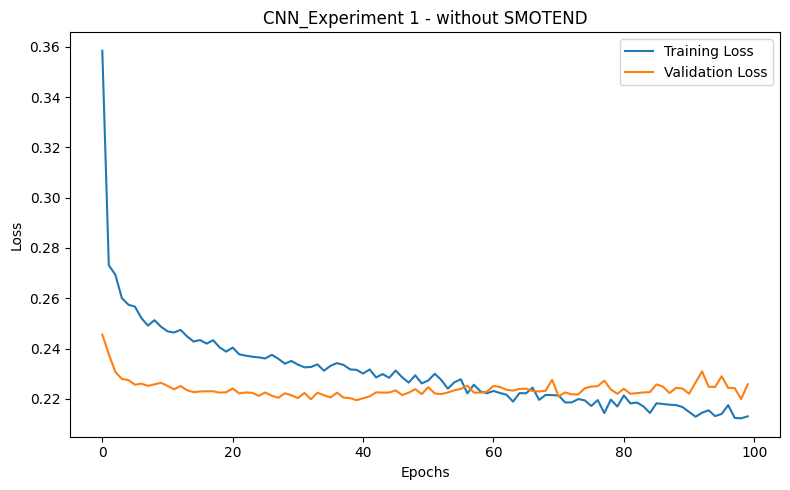

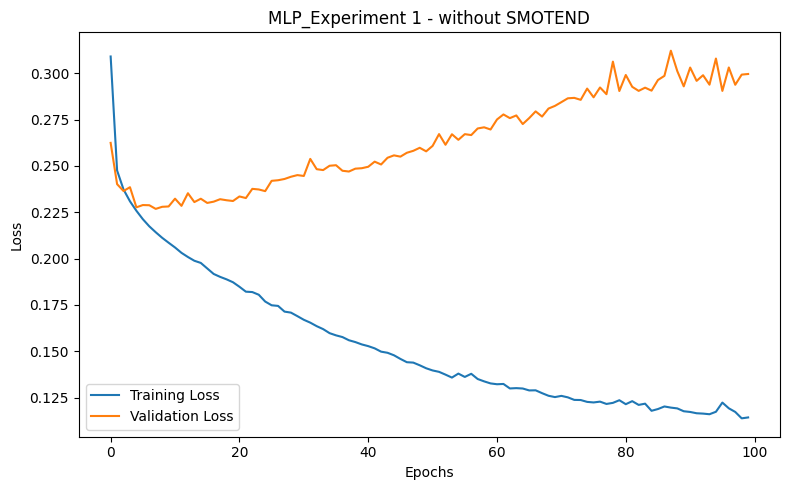

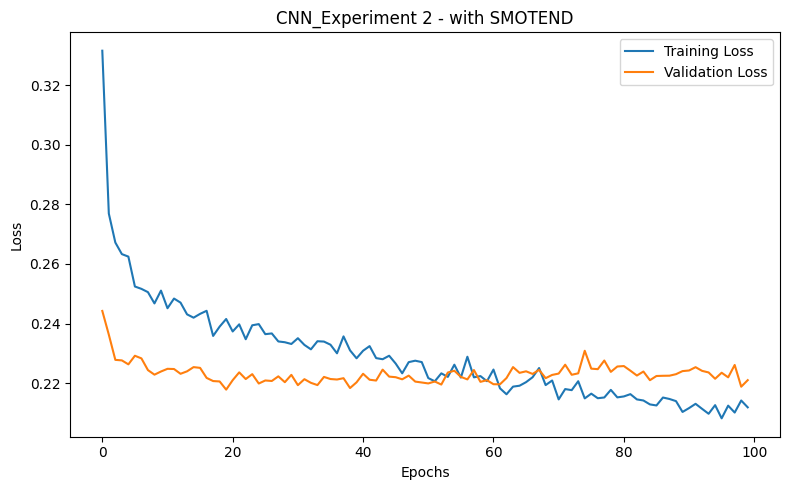

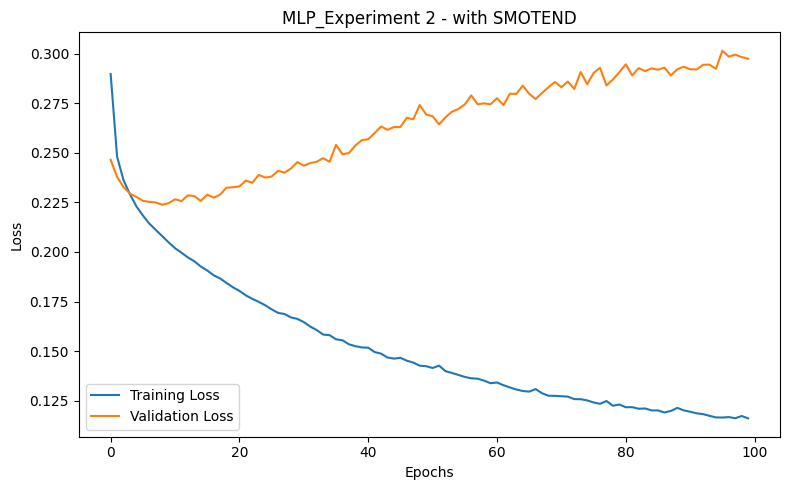

In [33]:
def plot_loss(history, title: str, filename: str):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()

for key, history in histories.items():
    filename = key.lower().replace(" ", "_").replace("-", "").replace("/", "_") + ".png"
    plot_loss(history, key, filename)

## 15. Baseline Machine Learning: DTR và SVR

Phần này tương ứng với bảng so sánh ML models trong bài báo.

In [34]:
def train_ml_baselines(experiment_name, X_train, X_test, y_train, y_test):
    baseline_models = {
        "DTR": DecisionTreeRegressor(random_state=RANDOM_STATE),
        "SVR": SVR(kernel="rbf", C=10.0, epsilon=0.1),
    }

    rows = []
    trained = {}

    for name, model in baseline_models.items():
        print(f"Training {name} - {experiment_name}")
        model.fit(X_train, y_train)
        trained[name] = model

        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)

        rows.append({"Experiment": experiment_name, "Model": name, "Dataset": "Train", **evaluate_regression(y_train, pred_train)})
        rows.append({"Experiment": experiment_name, "Model": name, "Dataset": "Test", **evaluate_regression(y_test, pred_test)})

    return trained, rows

ml_results = []
ml_models = {}

for exp_name, Xtr, Xte, ytr, yte in experiments:
    trained, rows = train_ml_baselines(exp_name, Xtr, Xte, ytr, yte)
    ml_models[exp_name] = trained
    ml_results.extend(rows)

ml_results_df = pd.DataFrame(ml_results)
ml_results_df["Kendall"] = ml_results_df["Kendall"].round(3)
ml_results_df["MSE"] = ml_results_df["MSE"].round(3)

display(ml_results_df)
ml_results_df.to_csv(OUTPUT_DIR / "table_ml_baseline_results.csv", index=False)

Training DTR - Experiment 1 - without SMOTEND
Training SVR - Experiment 1 - without SMOTEND
Training DTR - Experiment 2 - with SMOTEND
Training SVR - Experiment 2 - with SMOTEND


,Experiment,Model,Dataset,Kendall,MSE
0,Experiment 1 - without SMOTEND,DTR,Train,0.802,0.045
1,Experiment 1 - without SMOTEND,DTR,Test,0.119,0.429
2,Experiment 1 - without SMOTEND,SVR,Train,0.469,0.170
3,Experiment 1 - without SMOTEND,SVR,Test,0.284,0.263
4,Experiment 2 - with SMOTEND,DTR,Train,0.802,0.045
5,Experiment 2 - with SMOTEND,DTR,Test,0.119,0.429
6,Experiment 2 - with SMOTEND,SVR,Train,0.469,0.170
7,Experiment 2 - with SMOTEND,SVR,Test,0.284,0.263


## 16. Tổng hợp kết quả và vẽ biểu đồ so sánh

,Experiment,Model,Dataset,Kendall,MSE
0,Experiment 1 - without SMOTEND,CNN,Test,0.302,0.231
1,Experiment 1 - without SMOTEND,CNN,Train,0.388,0.202
2,Experiment 1 - without SMOTEND,DTR,Test,0.119,0.429
3,Experiment 1 - without SMOTEND,DTR,Train,0.802,0.045
4,Experiment 1 - without SMOTEND,MLP,Test,0.222,0.299
5,Experiment 1 - without SMOTEND,MLP,Train,0.503,0.156
6,Experiment 1 - without SMOTEND,SVR,Test,0.284,0.263
7,Experiment 1 - without SMOTEND,SVR,Train,0.469,0.170
8,Experiment 2 - with SMOTEND,CNN,Test,0.309,0.229
9,Experiment 2 - with SMOTEND,CNN,Train,0.401,0.196


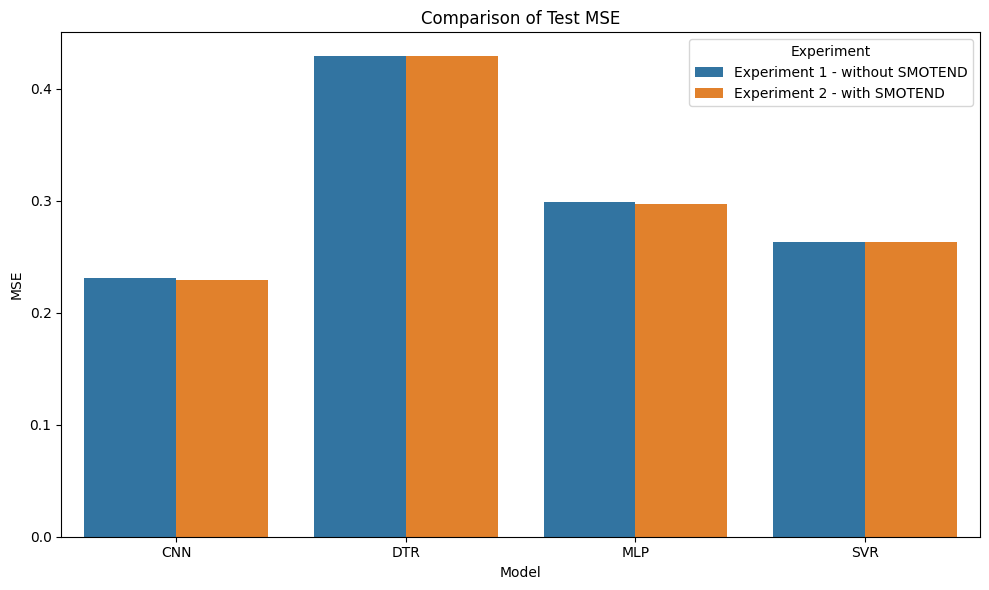

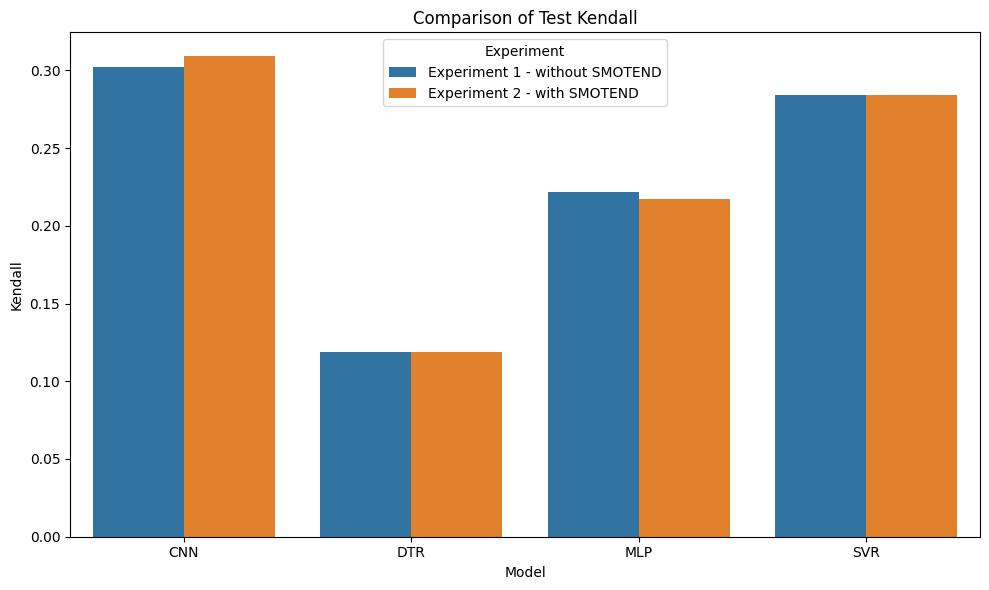

In [35]:
final_results_df = pd.concat([deep_results_df, ml_results_df], ignore_index=True)
final_results_df = final_results_df.sort_values(["Experiment", "Model", "Dataset"]).reset_index(drop=True)
display(final_results_df)
final_results_df.to_csv(OUTPUT_DIR / "final_all_results.csv", index=False)

test_results = final_results_df[final_results_df["Dataset"] == "Test"].copy()

plt.figure(figsize=(10, 6))
sns.barplot(data=test_results, x="Model", y="MSE", hue="Experiment")
plt.title("Comparison of Test MSE")
plt.xlabel("Model")
plt.ylabel("MSE")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_compare_test_mse.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=test_results, x="Model", y="Kendall", hue="Experiment")
plt.title("Comparison of Test Kendall")
plt.xlabel("Model")
plt.ylabel("Kendall")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_compare_test_kendall.png", dpi=200)
plt.show()

## 17. Nhận xét tự động cho báo cáo

In [36]:
best_by_mse = test_results.sort_values("MSE", ascending=True).iloc[0]
best_by_kendall = test_results.sort_values("Kendall", ascending=False).iloc[0]

print("Model tốt nhất theo Test MSE:")
print(best_by_mse)
print()
print("Model tốt nhất theo Test Kendall:")
print(best_by_kendall)

print("\nGợi ý nhận xét để đưa vào báo cáo:")
print(f"""
Kết quả thực nghiệm cho thấy mô hình {best_by_mse['Model']} trong {best_by_mse['Experiment']} đạt MSE thấp nhất trên tập test,
với MSE = {best_by_mse['MSE']} và Kendall = {best_by_mse['Kendall']}.
Khi so sánh giữa hai thí nghiệm, việc áp dụng SMOTEND-like oversampling giúp cải thiện phân bố dữ liệu,
giảm ảnh hưởng của hiện tượng mất cân bằng và hỗ trợ mô hình học ổn định hơn.
Các biểu đồ training loss và validation loss được lưu trong thư mục output để sử dụng trong báo cáo.
""")

Model tốt nhất theo Test MSE:
Experiment    Experiment 2 - with SMOTEND
Model                                 CNN
Dataset                              Test
Kendall                             0.309
MSE                                 0.229
Name: 8, dtype: object

Model tốt nhất theo Test Kendall:
Experiment    Experiment 2 - with SMOTEND
Model                                 CNN
Dataset                              Test
Kendall                             0.309
MSE                                 0.229
Name: 8, dtype: object

Gợi ý nhận xét để đưa vào báo cáo:

Kết quả thực nghiệm cho thấy mô hình CNN trong Experiment 2 - with SMOTEND đạt MSE thấp nhất trên tập test,
với MSE = 0.229 và Kendall = 0.309.
Khi so sánh giữa hai thí nghiệm, việc áp dụng SMOTEND-like oversampling giúp cải thiện phân bố dữ liệu,
giảm ảnh hưởng của hiện tượng mất cân bằng và hỗ trợ mô hình học ổn định hơn.
Các biểu đồ training loss và validation loss được lưu trong thư mục output để sử dụng trong báo cáo.



## 18. Lưu dataset đã xử lý và các file kết quả

In [37]:
clean_df.to_csv(OUTPUT_DIR / "merged_clean_lucene_poi_xalan.csv", index=False)
file_summary.to_csv(OUTPUT_DIR / "selected_files_summary.csv", index=False)

print("Các file quan trọng đã lưu trong thư mục:", OUTPUT_DIR.resolve())
for file in sorted(OUTPUT_DIR.glob("*")):
    print("-", file.name)

Các file quan trọng đã lưu trong thư mục: E:\Hoc Tap\HOC MAY_N\outputs_promise_fault_prediction
- cnn_experiment_1__without_smotend.png
- cnn_experiment_2__with_smotend.png
- fig_compare_test_kendall.png
- fig_compare_test_mse.png
- fig_distribution_after_smotend.png
- fig_distribution_log_transform.png
- fig_distribution_original_bug.png
- fig_full_correlation_matrix.png
- fig_hist_original_bug.png
- fig_strong_correlation_matrix.png
- final_all_results.csv
- merged_clean_lucene_poi_xalan.csv
- mlp_experiment_1__without_smotend.png
- mlp_experiment_2__with_smotend.png
- selected_files_summary.csv
- table_deep_learning_results.csv
- table_ml_baseline_results.csv


# Gợi ý viết vào báo cáo

Nhóm lựa chọn ba project Lucene, Poi và Xalan từ PROMISE bug-data. Các file CSV của nhiều version trong từng project được gộp thành một dataset chung. Sau đó, nhóm loại bỏ dữ liệu thiếu, dữ liệu trùng lặp và các cột định danh như tên class, project, version. Hai thí nghiệm được thực hiện: thí nghiệm thứ nhất sử dụng dữ liệu ban đầu, thí nghiệm thứ hai áp dụng SMOTEND-like oversampling nhằm xử lý mất cân bằng dữ liệu. Biến mục tiêu `bug` được biến đổi bằng `log1p` để giảm lệch phải, còn các đặc trưng đầu vào được chuẩn hóa bằng StandardScaler. Hai mô hình Deep Learning gồm CNN và MLP được xây dựng theo kiến trúc chia 20 đặc trưng thành 5 nhóm, mỗi nhóm 4 đặc trưng. Kết quả được đánh giá bằng MSE và Kendall, đồng thời biểu đồ training loss và validation loss được sử dụng để quan sát quá trình học của mô hình.